# EDA tổng hợp — NLBSE’23 Code Comment Classification

Notebook phân tích toàn bộ 4 file trong `data/`:

- `java.csv`, `pharo.csv`, `python.csv`: dữ liệu gốc dạng **long one-vs-rest**;
- `python_preprocessed.csv`: dữ liệu Python đã chuyển sang **wide multi-label**.

Mục tiêu là hiểu cấu trúc, đối soát 6.738 mẫu công bố, kiểm tra chất lượng dữ liệu, imbalance, label co-occurrence, text, duplicate và train/test drift giữa ba ngôn ngữ. File processed không được cộng như một dataset thứ tư vì nó là biến đổi của `python.csv`.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR_CANDIDATES = [Path('data'), Path('../data')]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if p.exists()), DATA_DIR_CANDIDATES[0])
RAW_FILES = {'Java': 'java.csv', 'Pharo': 'pharo.csv', 'Python': 'python.csv'}
PROCESSED_FILE = DATA_DIR / 'python_preprocessed.csv'

raw = {language: pd.read_csv(DATA_DIR / filename) for language, filename in RAW_FILES.items()}
python_processed = pd.read_csv(PROCESSED_FILE)
print('Data directory:', DATA_DIR.resolve())

Data directory: C:\Users\admin\OneDrive - Hanoi University of Science and Technology\Desktop\Insight\Master-Seminar-2\data


## 1. Inventory và data dictionary

### Raw long-format

| Cột | Ý nghĩa |
|---|---|
| `comment_sentence_id` | ID câu trong từng ngôn ngữ |
| `class` | class/source chứa comment |
| `comment_sentence` | nội dung câu |
| `partition` | 0=train, 1=test cho category hiện tại |
| `instance_type` | target nhị phân: 0=negative, 1=positive |
| `category` | category đang được xét |

### Processed wide-format

Mỗi ID chỉ còn một dòng; mỗi category trở thành một cột 0/1 và `label_count` là số nhãn dương.

In [2]:
inventory_rows = []
for language, df in raw.items():
    inventory_rows.append({
        'file': RAW_FILES[language], 'language': language, 'format': 'raw-long',
        'rows': len(df), 'columns': df.shape[1],
        'unique_sentences': df.comment_sentence_id.nunique(),
        'categories': df.category.nunique(), 'size_mb': (DATA_DIR / RAW_FILES[language]).stat().st_size / 1e6,
    })
inventory_rows.append({
    'file': PROCESSED_FILE.name, 'language': 'Python', 'format': 'processed-wide',
    'rows': len(python_processed), 'columns': python_processed.shape[1],
    'unique_sentences': python_processed.comment_sentence_id.nunique(),
    'categories': python_processed.shape[1] - 4, 'size_mb': PROCESSED_FILE.stat().st_size / 1e6,
})
inventory = pd.DataFrame(inventory_rows)
display(inventory.round({'size_mb': 3}))

official_sample_count = sum(df.comment_sentence_id.nunique() for df in raw.values())
print(f'Tổng số câu unique của ba ngôn ngữ: {official_sample_count:,}')
assert official_sample_count == 6738, 'Tổng số câu không khớp 6.738 mẫu công bố'

,file,language,format,rows,columns,unique_sentences,categories,size_mb
0,java.csv,Java,raw-long,16926,6,2418,7,1.485
1,pharo.csv,Pharo,raw-long,12355,6,1765,7,1.202
2,python.csv,Python,raw-long,12775,6,2555,5,0.920
3,python_preprocessed.csv,Python,processed-wide,2555,9,2555,5,0.179


Tổng số câu unique của ba ngôn ngữ: 6,738


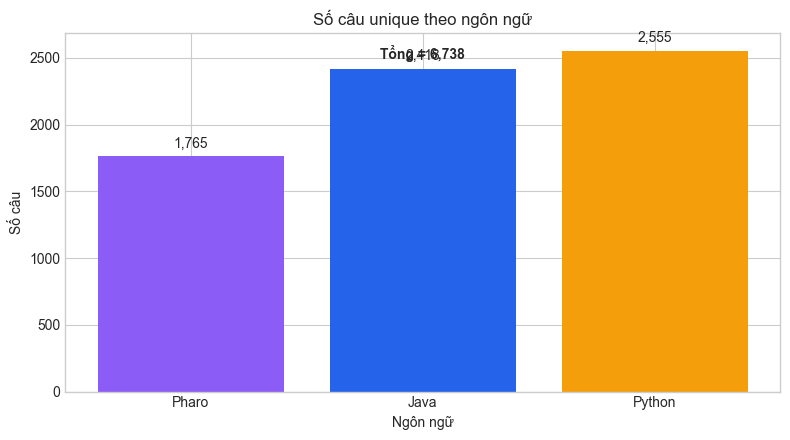

In [3]:
sample_counts = pd.Series(
    {language: df.comment_sentence_id.nunique() for language, df in raw.items()},
    name='sentences'
).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(sample_counts.index, sample_counts.values, color=['#8b5cf6', '#2563eb', '#f59e0b'])
ax.bar_label(bars, labels=[f'{v:,}' for v in sample_counts.values], padding=4)
ax.set(title='Số câu unique theo ngôn ngữ', xlabel='Ngôn ngữ', ylabel='Số câu')
ax.text(0.5, 0.93, f'Tổng = {sample_counts.sum():,}', transform=ax.transAxes, ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Kiểm tra schema và tính toàn vẹn

,missing_cells,exact_duplicate_rows,empty_text_rows,ids_with_multiple_texts,ids_with_multiple_classes,invalid_binary_targets,invalid_partitions,missing_columns
language,,,,,,,,
Java,0,0,0,0,0,0,0,None
Pharo,0,0,0,0,0,0,0,None
Python,0,0,0,0,0,0,0,None


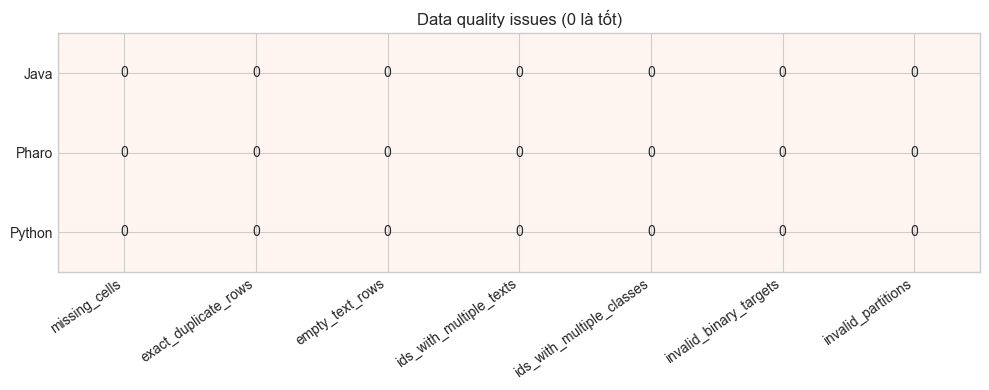

In [4]:
required = {'comment_sentence_id','class','comment_sentence','partition','instance_type','category'}
quality_rows = []
for language, df in raw.items():
    group = df.groupby('comment_sentence_id')
    quality_rows.append({
        'language': language,
        'missing_cells': int(df.isna().sum().sum()),
        'exact_duplicate_rows': int(df.duplicated().sum()),
        'empty_text_rows': int(df.comment_sentence.astype(str).str.strip().eq('').sum()),
        'ids_with_multiple_texts': int(group.comment_sentence.nunique().gt(1).sum()),
        'ids_with_multiple_classes': int(group['class'].nunique().gt(1).sum()),
        'invalid_binary_targets': int((~df.instance_type.isin([0, 1])).sum()),
        'invalid_partitions': int((~df.partition.isin([0, 1])).sum()),
        'missing_columns': ', '.join(sorted(required - set(df.columns))) or 'None',
    })
quality = pd.DataFrame(quality_rows).set_index('language')
display(quality)

numeric_quality = quality.drop(columns='missing_columns')
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(numeric_quality.to_numpy(), cmap='Reds', aspect='auto')
ax.set_xticks(range(numeric_quality.shape[1]), numeric_quality.columns, rotation=35, ha='right')
ax.set_yticks(range(len(numeric_quality)), numeric_quality.index)
for i in range(numeric_quality.shape[0]):
    for j in range(numeric_quality.shape[1]):
        ax.text(j, i, str(numeric_quality.iloc[i, j]), ha='center', va='center')
ax.set_title('Data quality issues (0 là tốt)')
plt.tight_layout()
plt.show()

In [5]:
structure_rows = []
for language, df in raw.items():
    n_categories = df.category.nunique()
    per_id = df.groupby('comment_sentence_id').agg(rows=('category','size'), categories=('category','nunique'))
    structure_rows.append({
        'language': language,
        'n_categories': n_categories,
        'min_rows_per_id': per_id.rows.min(),
        'max_rows_per_id': per_id.rows.max(),
        'ids_with_incomplete_category_set': int((per_id.categories != n_categories).sum()),
    })
structure = pd.DataFrame(structure_rows).set_index('language')
display(structure)
assert (structure.ids_with_incomplete_category_set == 0).all()

categories_by_language = pd.DataFrame({
    language: pd.Series(sorted(df.category.unique())) for language, df in raw.items()
})
display(categories_by_language.fillna(''))

,n_categories,min_rows_per_id,max_rows_per_id,ids_with_incomplete_category_set
language,,,,
Java,7,7,7,0
Pharo,7,7,7,0
Python,5,5,5,0


,Java,Pharo,Python
0,Expand,Classreferences,DevelopmentNotes
1,Ownership,Collaborators,Expand
2,Pointer,Example,Parameters
3,deprecation,Intent,Summary
4,rational,Keyimplementationpoints,Usage
5,summary,Keymessages,
6,usage,Responsibilities,


## 3. Encode wide multi-label và label cardinality

`instance_type` là target, còn `category` là tên nhãn. Pivot hai cột này tạo ma trận multi-hot phục vụ EDA và joint multi-label models.

In [6]:
wide = {}
metadata = {}
for language, df in raw.items():
    metadata[language] = (
        df[['comment_sentence_id','class','comment_sentence']]
        .drop_duplicates('comment_sentence_id')
        .set_index('comment_sentence_id')
    )
    wide[language] = (
        df.pivot(index='comment_sentence_id', columns='category', values='instance_type')
        .astype('int8').sort_index(axis=1)
    )
    assert not wide[language].isna().any().any()

multi_label_summary = []
for language, y in wide.items():
    counts = y.sum(axis=1)
    multi_label_summary.append({
        'language': language, 'samples': len(y), 'labels': y.shape[1],
        'label_cardinality': counts.mean(), 'label_density': counts.mean()/y.shape[1],
        'min_positive_labels': counts.min(), 'max_positive_labels': counts.max(),
        'samples_without_label': int((counts == 0).sum()),
    })
multi_label_summary = pd.DataFrame(multi_label_summary).set_index('language')
display(multi_label_summary.round(3))

,samples,labels,label_cardinality,label_density,min_positive_labels,max_positive_labels,samples_without_label
language,,,,,,,
Java,2418,7,1.177,0.168,1,3,0
Pharo,1765,7,1.158,0.165,1,4,0
Python,2555,5,1.121,0.224,1,3,0


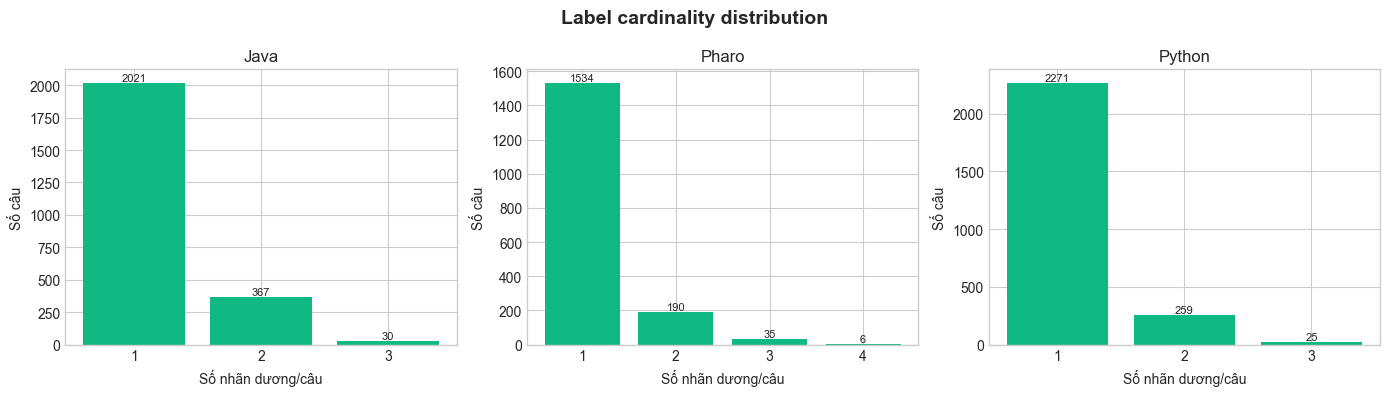

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (language, y) in zip(axes, wide.items()):
    distribution = y.sum(axis=1).value_counts().sort_index()
    bars = ax.bar(distribution.index.astype(str), distribution.values, color='#10b981')
    ax.bar_label(bars, fontsize=8)
    ax.set(title=language, xlabel='Số nhãn dương/câu', ylabel='Số câu')
fig.suptitle('Label cardinality distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Imbalance và phân bố nhãn

,language,label,positive,negative,prevalence,neg_pos_ratio
1,Java,Ownership,115,2303,0.048,20.026
3,Java,deprecation,127,2291,0.053,18.039
4,Java,rational,280,2138,0.116,7.636
2,Java,Pointer,364,2054,0.151,5.643
5,Java,summary,415,2003,0.172,4.827
0,Java,Expand,632,1786,0.261,2.826
6,Java,usage,912,1506,0.377,1.651
7,Pharo,Classreferences,77,1688,0.044,21.922
8,Pharo,Collaborators,127,1638,0.072,12.898
10,Pharo,Intent,218,1547,0.124,7.096


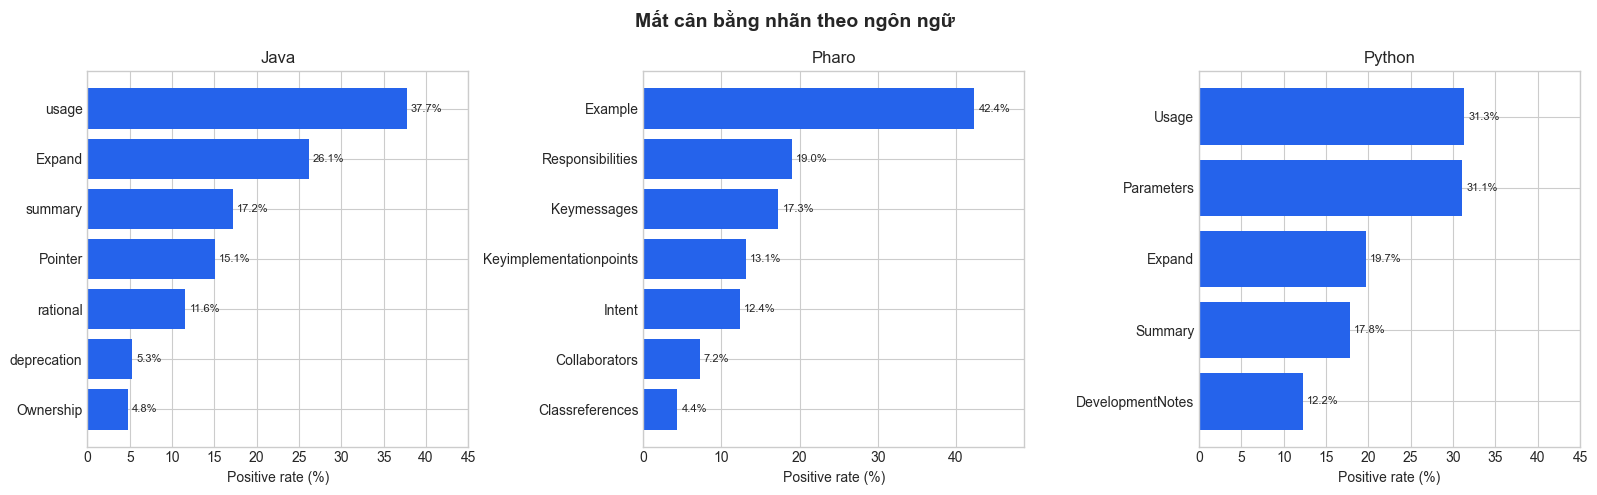

In [8]:
prevalence_records = []
for language, y in wide.items():
    for label in y.columns:
        positive = int(y[label].sum())
        prevalence_records.append({
            'language': language, 'label': label, 'positive': positive,
            'negative': len(y)-positive, 'prevalence': positive/len(y),
            'neg_pos_ratio': (len(y)-positive)/positive if positive else np.inf,
        })
prevalence = pd.DataFrame(prevalence_records)
display(prevalence.sort_values(['language','prevalence']).round(3))

languages = list(raw)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, language in zip(axes, languages):
    plot_df = prevalence.query('language == @language').sort_values('prevalence')
    bars = ax.barh(plot_df.label, plot_df.prevalence * 100, color='#2563eb')
    ax.bar_label(bars, labels=[f'{v:.1f}%' for v in plot_df.prevalence*100], padding=3, fontsize=8)
    ax.set(title=language, xlabel='Positive rate (%)', ylabel='')
    ax.set_xlim(0, max(45, plot_df.prevalence.max()*115))
fig.suptitle('Mất cân bằng nhãn theo ngôn ngữ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Đồng xuất hiện giữa các nhãn

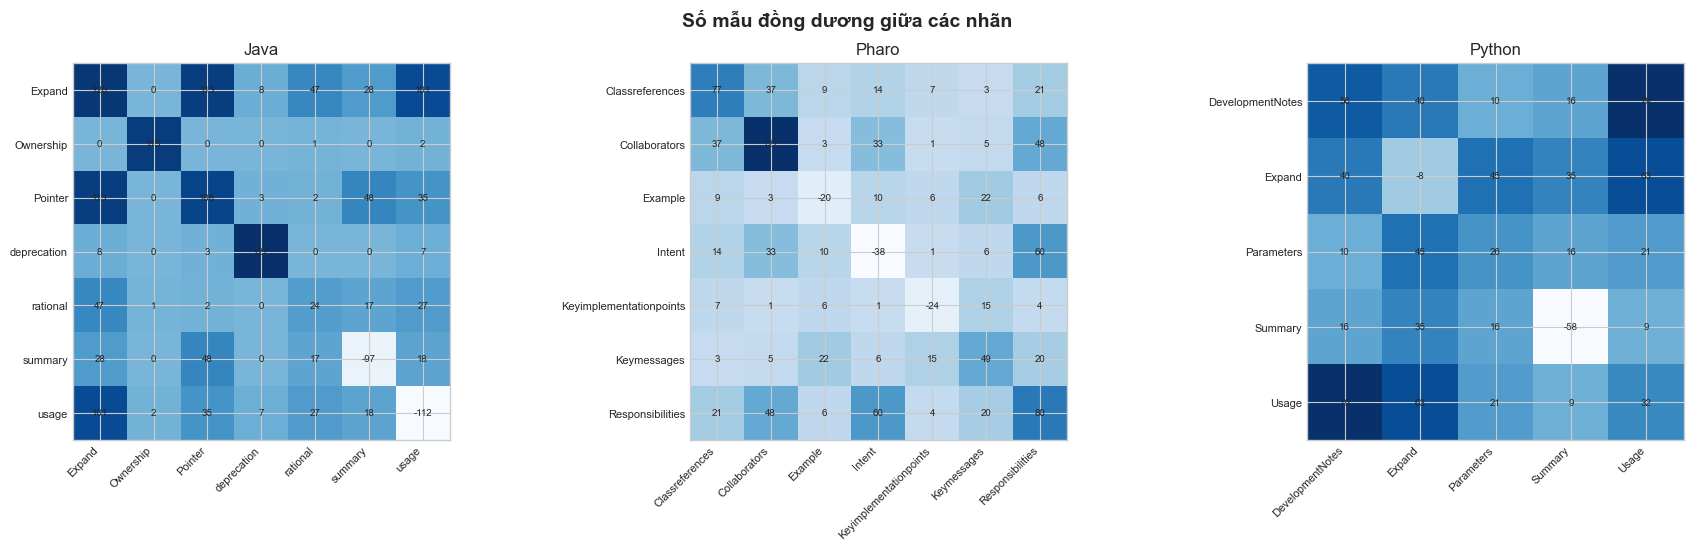

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (language, y) in zip(axes, wide.items()):
    cooc = y.T.dot(y).astype(int)
    image = ax.imshow(cooc, cmap='Blues')
    ax.set_xticks(range(len(cooc)), cooc.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(cooc)), cooc.index, fontsize=8)
    for i in range(len(cooc)):
        for j in range(len(cooc)):
            ax.text(j, i, str(cooc.iloc[i,j]), ha='center', va='center', fontsize=7)
    ax.set_title(language)
fig.suptitle('Số mẫu đồng dương giữa các nhãn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

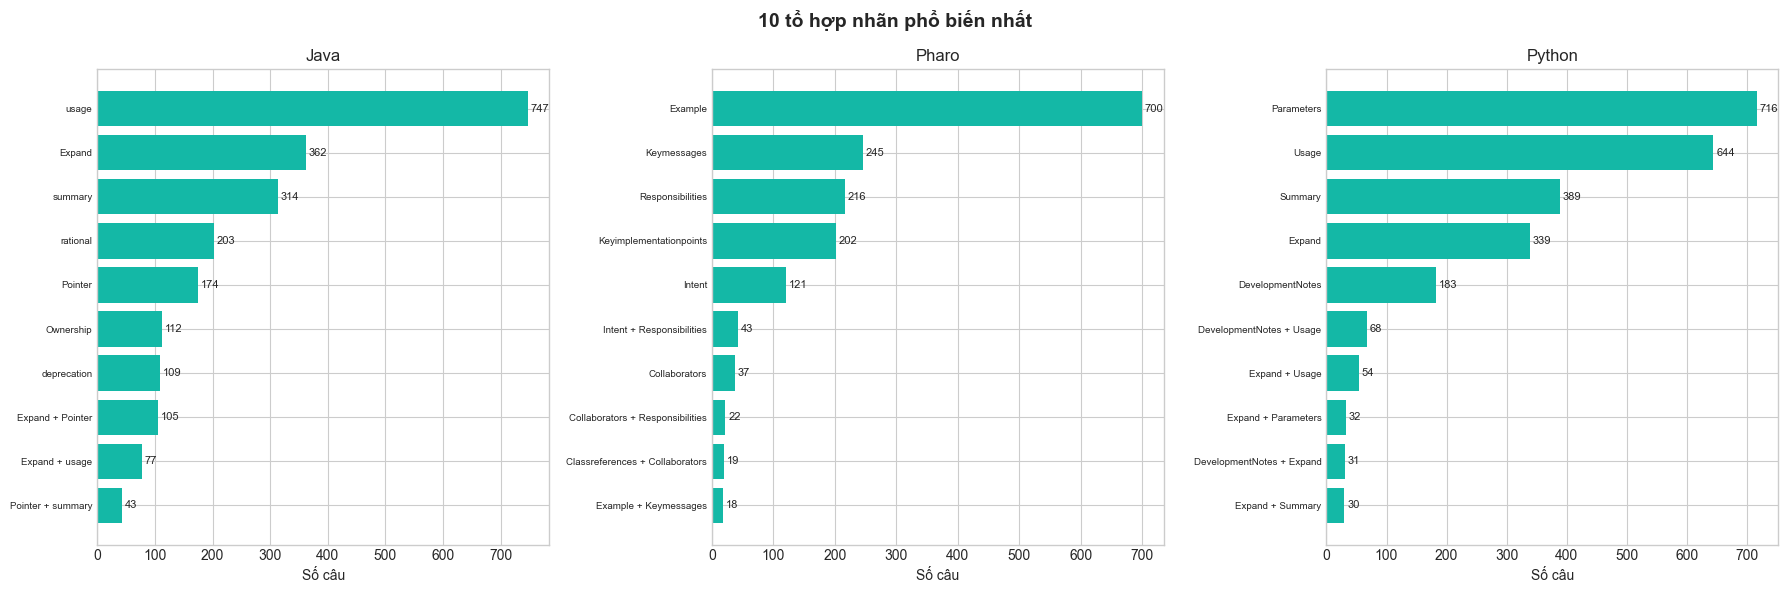

In [10]:
combination_tables = {}
for language, y in wide.items():
    combinations = y.apply(
        lambda row: ' + '.join(row.index[row.eq(1)].tolist()) or '(none)', axis=1
    ).value_counts()
    combination_tables[language] = combinations

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, language in zip(axes, languages):
    top = combination_tables[language].head(10).sort_values()
    bars = ax.barh(top.index, top.values, color='#14b8a6')
    ax.bar_label(bars, fontsize=8, padding=2)
    ax.set(title=language, xlabel='Số câu', ylabel='')
    ax.tick_params(axis='y', labelsize=7)
fig.suptitle('10 tổ hợp nhãn phổ biến nhất', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Phân tích text

word_len             char_len             
             mean median  max     mean median   max
language                                           
Java         7.39    7.0  125    45.79   43.0  1321
Pharo        8.68    7.0   45    54.18   44.0   375
Python       6.73    6.0   20    38.70   37.0   103

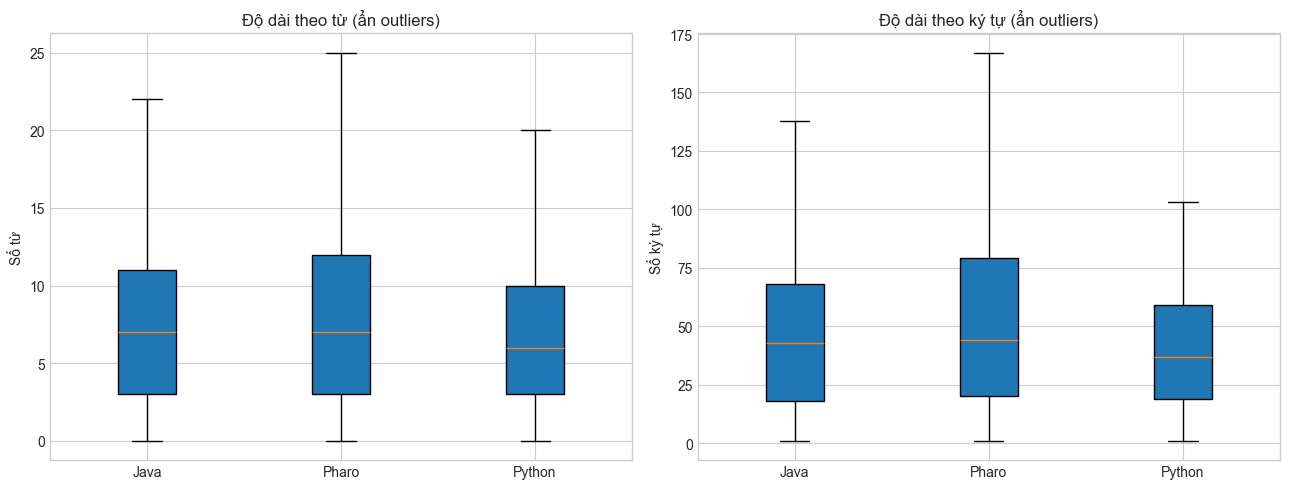

In [11]:
text_frames = []
for language, meta in metadata.items():
    temp = meta.reset_index().copy()
    temp['language'] = language
    temp['char_len'] = temp.comment_sentence.astype(str).str.len()
    temp['word_len'] = temp.comment_sentence.astype(str).str.findall(r'\b\w+\b').str.len()
    temp['normalized_text'] = temp.comment_sentence.astype(str).str.lower().str.replace(r'\s+',' ',regex=True).str.strip()
    temp['is_lowercase'] = temp.comment_sentence.eq(temp.comment_sentence.str.lower())
    temp['ends_punctuation'] = temp.comment_sentence.str.contains(r'[.!?]$')
    temp['has_code_token'] = temp.comment_sentence.str.contains(r'[_().=]|\b(?:class|def|return|None|True|False)\b', regex=True)
    text_frames.append(temp)
texts = pd.concat(text_frames, ignore_index=True)

length_summary = texts.groupby('language')[['word_len','char_len']].agg(['mean','median','max'])
display(length_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
word_data = [texts.loc[texts.language.eq(lang),'word_len'] for lang in languages]
char_data = [texts.loc[texts.language.eq(lang),'char_len'] for lang in languages]
axes[0].boxplot(word_data, tick_labels=languages, showfliers=False, patch_artist=True)
axes[0].set(title='Độ dài theo từ (ẩn outliers)', ylabel='Số từ')
axes[1].boxplot(char_data, tick_labels=languages, showfliers=False, patch_artist=True)
axes[1].set(title='Độ dài theo ký tự (ẩn outliers)', ylabel='Số ký tự')
plt.tight_layout()
plt.show()

,samples,one_word_or_less,three_words_or_less,lowercase_rate,punctuation_end_rate,code_token_rate,normalized_duplicate_rows
language,,,,,,,
Java,2418,270,783,1.000,0.383,0.444,1002
Pharo,1765,200,538,0.999,0.557,0.586,205
Python,2555,283,704,0.997,0.356,0.392,368


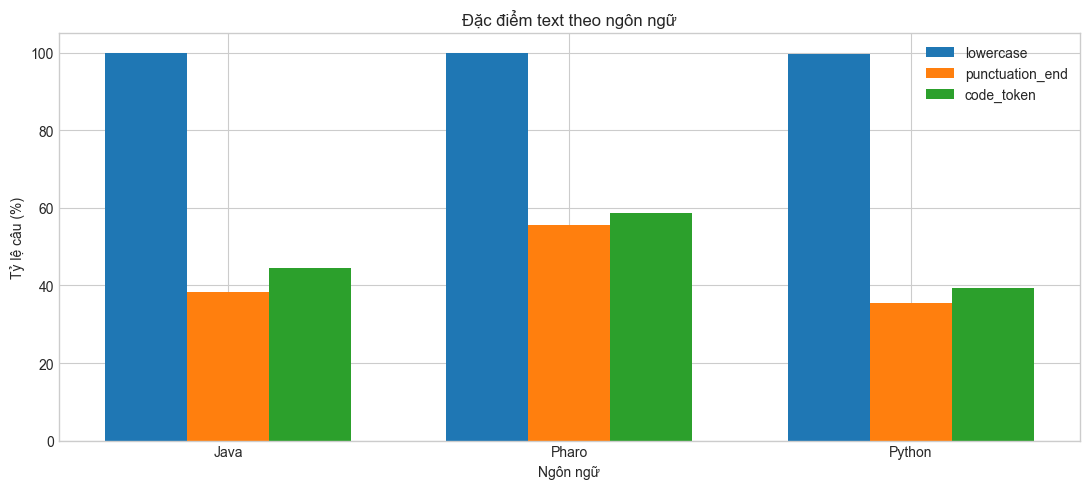

In [12]:
text_quality = texts.groupby('language').agg(
    samples=('comment_sentence_id','size'),
    one_word_or_less=('word_len', lambda s: int(s.le(1).sum())),
    three_words_or_less=('word_len', lambda s: int(s.le(3).sum())),
    lowercase_rate=('is_lowercase','mean'),
    punctuation_end_rate=('ends_punctuation','mean'),
    code_token_rate=('has_code_token','mean'),
    normalized_duplicate_rows=('normalized_text', lambda s: int(s.duplicated(keep=False).sum())),
)
display(text_quality.round(3))

rate_cols = ['lowercase_rate','punctuation_end_rate','code_token_rate']
plot_rates = text_quality[rate_cols] * 100
x = np.arange(len(plot_rates))
width = 0.24
fig, ax = plt.subplots(figsize=(11, 5))
for j, col in enumerate(rate_cols):
    ax.bar(x + (j-1)*width, plot_rates[col], width, label=col.replace('_rate',''))
ax.set_xticks(x, plot_rates.index)
ax.set(title='Đặc điểm text theo ngôn ngữ', ylabel='Tỷ lệ câu (%)', xlabel='Ngôn ngữ')
ax.legend()
plt.tight_layout()
plt.show()

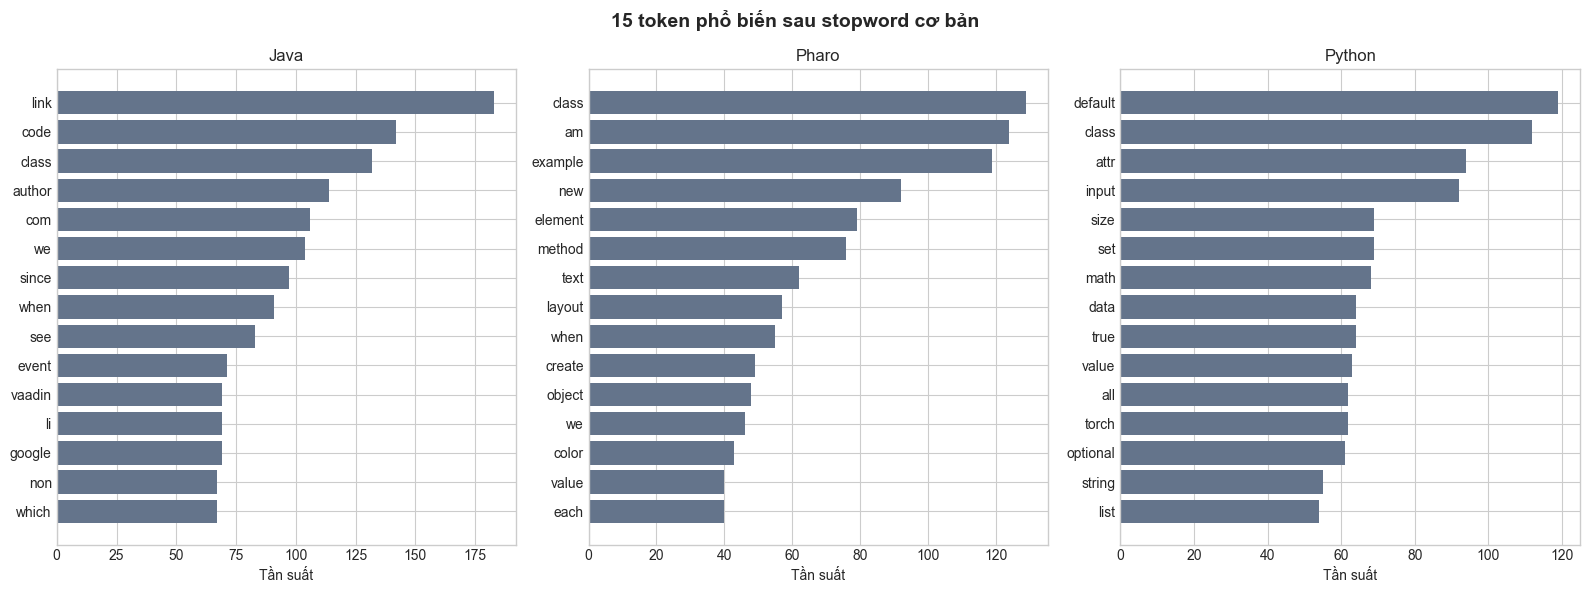

In [13]:
stopwords = {'a','an','the','and','or','of','to','in','for','is','are','be','this','that','with','as','on','by','from','it','if','not','will','can','used','using'}
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
top_tokens_by_language = {}
for ax, language in zip(axes, languages):
    tokens = (texts.loc[texts.language.eq(language),'comment_sentence']
              .str.lower().str.findall(r'[a-zA-Z_][a-zA-Z_0-9]+').explode())
    top = tokens[~tokens.isin(stopwords)].value_counts().head(15).sort_values()
    top_tokens_by_language[language] = top
    ax.barh(top.index, top.values, color='#64748b')
    ax.set(title=language, xlabel='Tần suất')
fig.suptitle('15 token phổ biến sau stopword cơ bản', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Class concentration và duplicate cross-language

,unique_classes,median_sentences_per_class,classes_with_one_sentence,top_10_class_share
language,,,,
Java,348,2.0,138,0.441
Pharo,328,2.0,138,0.241
Python,330,2.0,145,0.306


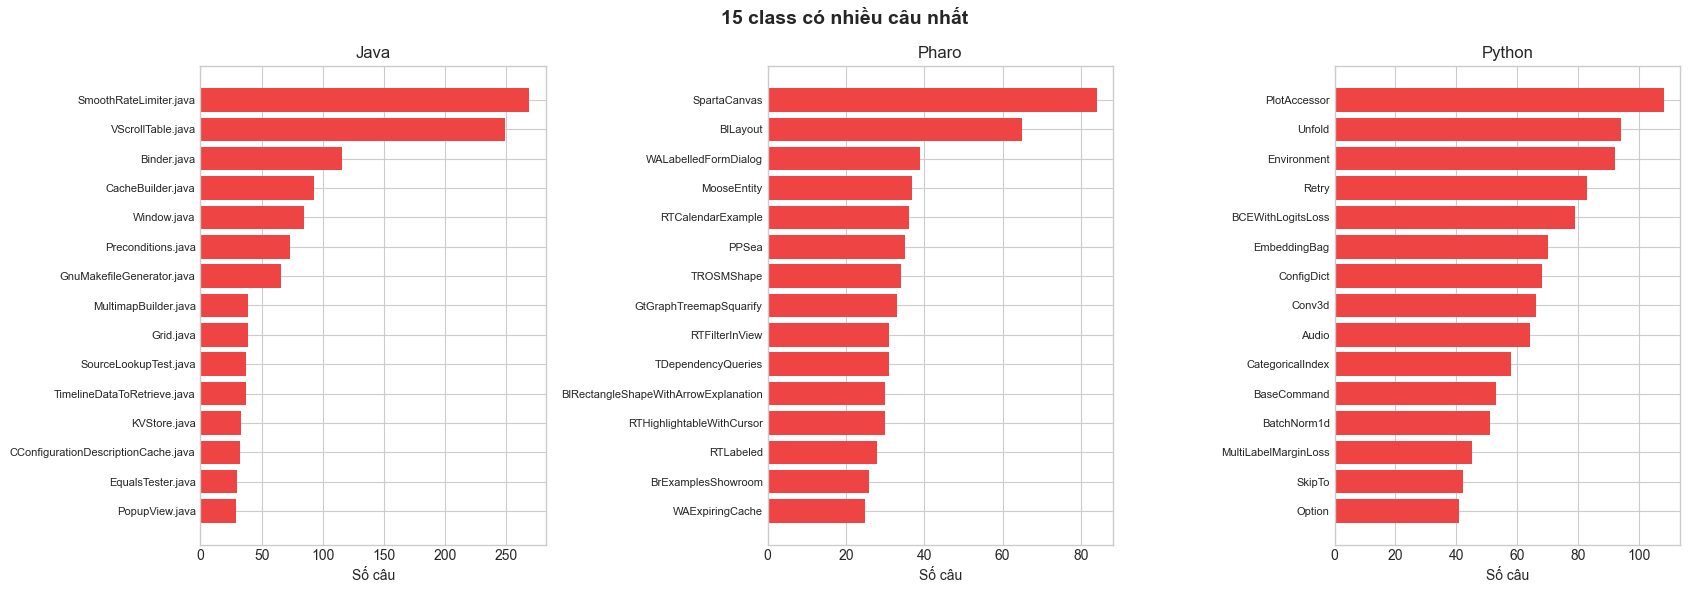

In [14]:
class_summary = []
for language, frame in texts.groupby('language'):
    counts = frame['class'].value_counts()
    class_summary.append({
        'language': language, 'unique_classes': counts.size,
        'median_sentences_per_class': counts.median(),
        'classes_with_one_sentence': int(counts.eq(1).sum()),
        'top_10_class_share': counts.head(10).sum()/counts.sum(),
    })
class_summary = pd.DataFrame(class_summary).set_index('language')
display(class_summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, language in zip(axes, languages):
    top = texts.loc[texts.language.eq(language),'class'].value_counts().head(15).sort_values()
    ax.barh(top.index, top.values, color='#ef4444')
    ax.set(title=language, xlabel='Số câu')
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle('15 class có nhiều câu nhất', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
within_duplicates = texts.groupby('language').normalized_text.apply(lambda s: s.duplicated(keep=False).sum())
cross_language = texts.groupby('normalized_text').language.nunique()
cross_language_texts = cross_language[cross_language.gt(1)]

display(pd.DataFrame({
    'within_language_duplicate_rows': within_duplicates,
}))
print(f'Normalized texts xuất hiện ở từ hai ngôn ngữ trở lên: {len(cross_language_texts):,}')

if len(cross_language_texts):
    examples = texts[texts.normalized_text.isin(cross_language_texts.index)]         .sort_values(['normalized_text','language'])[['language','class','comment_sentence']].head(20)
    display(examples)

,within_language_duplicate_rows
language,
Java,1002
Pharo,205
Python,368


Normalized texts xuất hiện ở từ hai ngôn ngữ trở lên: 18


,language,class,comment_sentence
93,Java,TextInputFormat.java,.
685,Java,SourceLookupTest.java,.
691,Java,SourceLookupTest.java,.
694,Java,SourceLookupTest.java,.
697,Java,SourceLookupTest.java,.
3229,Pharo,PPSea,.
3424,Pharo,RTCalendarExample,.
3441,Pharo,RTCalendarExample,.
4304,Python,RawPostDataException,.
4491,Python,Magics,.


## 8. Official train/test split và distribution drift

`partition` thuộc từng cặp `(sentence, category)`. Phần này so sánh positive rate giữa train/test của từng binary task. Chênh lệch nhỏ cho thấy stratification hoạt động tốt; không đồng nghĩa text distribution hoàn toàn giống nhau.

,split,Test,Train,abs_gap_pp
language,category,,,
Pharo,Collaborators,0.0780,0.0704,0.7582
Java,summary,0.1776,0.1701,0.7427
Pharo,Classreferences,0.0476,0.0426,0.5005
Python,DevelopmentNotes,0.1260,0.1211,0.4831
Java,Ownership,0.0511,0.0467,0.4468
Pharo,Keymessages,0.1760,0.1720,0.3980
Java,deprecation,0.0554,0.0518,0.3655
Pharo,Intent,0.1264,0.1228,0.3622
Java,Pointer,0.1534,0.1498,0.3556


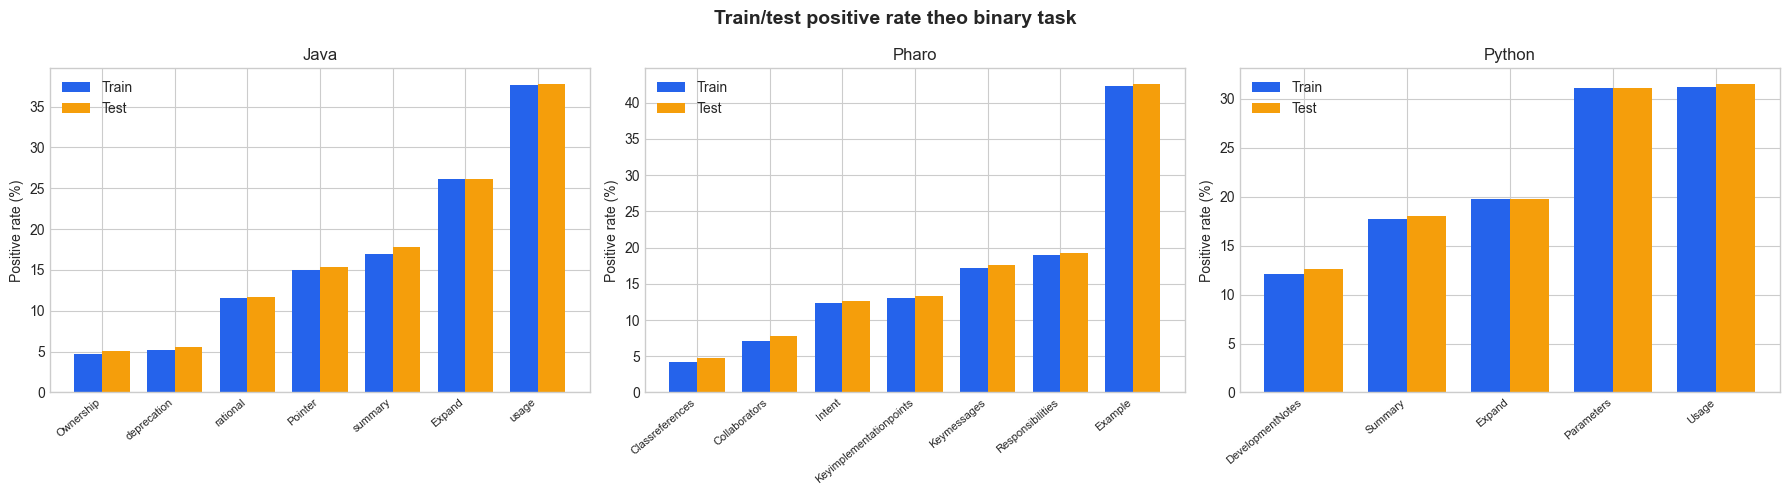

In [16]:
split_records = []
for language, df in raw.items():
    stats = df.groupby(['category','partition']).instance_type.agg(n='size', positive='sum', positive_rate='mean').reset_index()
    stats['language'] = language
    split_records.append(stats)
split_stats = pd.concat(split_records, ignore_index=True)
split_stats['split'] = split_stats.partition.map({0:'Train',1:'Test'})

rate_table = split_stats.pivot_table(index=['language','category'], columns='split', values='positive_rate')
rate_table['abs_gap_pp'] = (rate_table.Train-rate_table.Test).abs()*100
display(rate_table.sort_values('abs_gap_pp', ascending=False).round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, language in zip(axes, languages):
    table = rate_table.loc[language].sort_values('Train')
    x = np.arange(len(table)); width=.38
    ax.bar(x-width/2, table.Train*100, width, label='Train', color='#2563eb')
    ax.bar(x+width/2, table.Test*100, width, label='Test', color='#f59e0b')
    ax.set_xticks(x, table.index, rotation=40, ha='right', fontsize=8)
    ax.set(title=language, ylabel='Positive rate (%)')
    ax.legend()
fig.suptitle('Train/test positive rate theo binary task', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Đối soát `python_preprocessed.csv`

In [17]:
python_labels = wide['Python'].columns.tolist()
expected_python = metadata['Python'].join(wide['Python']).reset_index()
expected_python['comment_sentence'] = expected_python.comment_sentence.str.replace(r'\s+',' ',regex=True).str.strip()
expected_python['label_count'] = expected_python[python_labels].sum(axis=1).astype('int8')

checks = pd.Series({
    'row_count_matches': len(python_processed) == len(expected_python),
    'columns_match': set(python_processed.columns) == set(expected_python.columns),
    'unique_ids': not python_processed.comment_sentence_id.duplicated().any(),
    'no_missing': not python_processed.isna().any().any(),
    'labels_match_source': np.array_equal(
        python_processed.set_index('comment_sentence_id')[python_labels].sort_index().to_numpy(),
        wide['Python'].sort_index().to_numpy(),
    ),
    'labels_are_integer': all(pd.api.types.is_integer_dtype(python_processed[label]) for label in python_labels),
    'label_count_correct': python_processed.label_count.equals(python_processed[python_labels].sum(axis=1)),
}, name='passed').to_frame()
checks['status'] = checks.passed.map({True:'PASS',False:'REVIEW'})
display(checks[['status']])
assert checks.passed.all(), 'python_preprocessed.csv chưa khớp dữ liệu nguồn'

,status
row_count_matches,PASS
columns_match,PASS
unique_ids,PASS
no_missing,PASS
labels_match_source,PASS
labels_are_integer,PASS
label_count_correct,PASS


## 10. Insight và quyết định cho pipeline

1. **6.738 là tổng ba ngôn ngữ**, không phải số mẫu Python. Java có 2.418, Pharo 1.765 và Python 2.555 câu.
2. **Số nhãn khác nhau theo ngôn ngữ**: Java và Pharo có 7 category, Python có 5. Không ghép output head mà không định nghĩa label space chung.
3. **Bài toán multi-label nhưng dữ liệu gốc là long one-vs-rest**. Official reproduction nên huấn luyện một binary classifier/category theo `partition`; joint model cần pivot wide.
4. **Imbalance phải đánh giá theo từng language–label**. Dùng per-label F1/precision/recall, macro-F1, micro-F1 và PR-AUC; accuracy đơn lẻ không phù hợp.
5. **Comment thường ngắn và nhiều fragment**. Chỉ chuẩn hóa whitespace; không xóa mạnh code tokens/API names. Với Transformer, chọn `max_length` từ tokenizer percentile thay vì mặc định 512.
6. **Duplicate và class concentration có thể gây leakage**. Với k-fold, group theo normalized text; GroupKFold theo `class` là robustness test cho unseen APIs/classes.
7. **Official split khá ổn định về positive rate**, nhưng cần kiểm tra thêm text/class drift khi phân tích kết quả.
8. **`python_preprocessed.csv` đã đối soát với nguồn**, có thể dùng trực tiếp cho joint Python model; Java và Pharo cần tạo wide artifact tương tự nếu huấn luyện joint model.

### Artifact đề xuất

- `data/{language}_preprocessed.csv` hoặc Parquet: một dòng/câu;
- `configs/label_map_{language}.json`: thứ tự nhãn cố định;
- `results/eda_summary.csv`: prevalence, cardinality và length statistics;
- `experiments/*/folds.csv`: ID/group → fold để mọi model dùng cùng split.

In [18]:
# Bảng tóm tắt cuối cùng dùng cho report
final_summary = multi_label_summary.join(class_summary).join(
    text_quality[['lowercase_rate','punctuation_end_rate','code_token_rate','normalized_duplicate_rows']]
)
final_summary['rarest_label'] = prevalence.loc[prevalence.groupby('language').prevalence.idxmin()].set_index('language').label
final_summary['rarest_prevalence'] = prevalence.groupby('language').prevalence.min()
final_summary['max_train_test_gap_pp'] = rate_table.groupby(level='language').abs_gap_pp.max()
display(final_summary.round(3))

,samples,labels,label_cardinality,label_density,min_positive_labels,max_positive_labels,samples_without_label,unique_classes,median_sentences_per_class,classes_with_one_sentence,top_10_class_share,lowercase_rate,punctuation_end_rate,code_token_rate,normalized_duplicate_rows,rarest_label,rarest_prevalence,max_train_test_gap_pp
language,,,,,,,,,,,,,,,,,,
Java,2418,7,1.177,0.168,1,3,0,348,2.0,138,0.441,1.000,0.383,0.444,1002,Ownership,0.048,0.743
Pharo,1765,7,1.158,0.165,1,4,0,328,2.0,138,0.241,0.999,0.557,0.586,205,Classreferences,0.044,0.758
Python,2555,5,1.121,0.224,1,3,0,330,2.0,145,0.306,0.997,0.356,0.392,368,DevelopmentNotes,0.122,0.483
